# Tarea 1 — Limpieza y Análisis Inicial de Datos con Python y Pandas

**Universidad San Carlos de Guatemala — Facultad de Ingeniería**
**Ingeniería en Ciencias y Sistemas — Seminario de Sistemas 2**

| | |
|---|---|
| **Grupo** | 8 |
| **Dataset** | `dataset_sucio.csv` (dataset de clientes y transacciones provisto para la actividad) |
| **Ponderación** | 1.66 ptos |

## Objetivo

Aplicar un proceso completo de limpieza de datos sobre `dataset_sucio.csv` utilizando Python y Pandas —eliminación de
duplicados, tratamiento de valores faltantes y estandarización de formatos— y generar tablas y visualizaciones que
permitan analizar la calidad de los datos antes y después del tratamiento, así como las relaciones entre variables.

## Contenido

1. Carga del dataset
2. Diagnóstico de calidad — estado **antes**
3. Limpieza y transformación de datos
4. Diagnóstico de calidad — estado **después**
5. Tablas tipo pivote (antes vs. después)
6. Visualizaciones y análisis de relaciones
7. Exportación del dataset limpio
8. Conclusiones

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

IMG_DIR = "imgs"
os.makedirs(IMG_DIR, exist_ok=True)

RUTA_DATASET = "dataset_sucio.csv"

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## Funciones auxiliares

Se definen funciones reutilizables para: (1) exportar un `DataFrame` como imagen (para documentar tablas en el
`README.md`), (2) estandarizar texto, (3) interpretar fechas en múltiples formatos y (4) interpretar montos con
separador decimal inconsistente (coma o punto).

In [2]:
def save_df_image(df, filename, title=None, max_rows=20):
    """Renderiza un DataFrame como imagen PNG (tabla) para usar como evidencia/captura en README.md."""
    data = df.head(max_rows).reset_index()
    n_rows, n_cols = data.shape
    fig_w = min(2.0 * n_cols, 18)
    fig_h = 0.42 * (n_rows + 1) + (0.8 if title else 0.4)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis("off")
    if title:
        ax.set_title(title, fontsize=13, fontweight="bold", pad=14)
    tabla = ax.table(
        cellText=data.values,
        colLabels=data.columns,
        cellLoc="center",
        loc="center",
    )
    tabla.auto_set_font_size(False)
    tabla.set_fontsize(9)
    tabla.scale(1, 1.6)
    tabla.auto_set_column_width(col=list(range(n_cols)))
    for (row, col), cell in tabla.get_celld().items():
        if row == 0:
            cell.set_facecolor("#2b3a67")
            cell.set_text_props(color="white", fontweight="bold")
        else:
            cell.set_facecolor("#f4f6fb" if row % 2 == 0 else "white")
    fig.tight_layout()
    ruta = os.path.join(IMG_DIR, filename)
    fig.savefig(ruta, bbox_inches="tight")
    plt.close(fig)
    print(f"Imagen guardada: {ruta}")


def limpiar_texto(serie):
    """Elimina espacios al inicio/fin, colapsa espacios internos múltiples a uno solo."""
    return serie.astype("string").str.strip().str.replace(r"\s+", " ", regex=True)


def parsear_fecha(valor):
    """Interpreta fechas registradas en dos formatos distintos: 'YYYY-MM-DD' y 'DD/MM/YYYY'."""
    for fmt in ("%Y-%m-%d", "%d/%m/%Y"):
        try:
            return pd.to_datetime(valor, format=fmt)
        except (ValueError, TypeError):
            continue
    return pd.NaT


def parsear_gasto(valor):
    """Interpreta montos con separador decimal inconsistente: '371.80' (punto) o '373,33' (coma)."""
    if pd.isna(valor):
        return np.nan
    texto = str(valor).strip().strip('"')
    if texto == "":
        return np.nan
    if "," in texto and "." not in texto:
        texto = texto.replace(",", ".")
    elif "," in texto and "." in texto:
        texto = texto.replace(",", "")
    try:
        return float(texto)
    except ValueError:
        return np.nan

print("Funciones auxiliares definidas.")

Funciones auxiliares definidas.


## 1. Carga del dataset

El dataset contiene información de clientes y su gasto asociado a una categoría de compra, incluyendo su fecha de
registro y ciudad. Se carga tal cual fue provisto, sin ninguna transformación, para documentar su estado original.

In [3]:
df_raw = pd.read_csv(RUTA_DATASET)
print(f"Dimensiones del dataset original: {df_raw.shape[0]} filas x {df_raw.shape[1]} columnas")
df_raw.head(10)

Dimensiones del dataset original: 5000 filas x 7 columnas


,id_cliente,nombre,genero,fecha_registro,gasto_q,ciudad,categoria
0,502609,Paola Morales,m,2026-02-27,NaN,Antigua,Retail
1,500588,ANA DIAZ,f,2026-02-24,371.80,Villa Nueva,Services
2,502408,Maria Paz,m,2026-01-15,"373,33",quetzaltenango,retail
3,501688,Ana Mejia,f,2026-01-18,361.23,Quetzaltenango,Education
4,502916,Carlos Mendez,f,29/01/2026,"339,01",Amatitlan,Retail
5,504200,Oscar Rojas,m,2026-01-09,138.22,Antigua,RETAIL
6,502029,Isabel Ramirez,m,2026-02-05,"166,31",Villa Nueva,SERVICES
7,501366,Pedro Herrera,m,12/02/2026,"405,62",Amatitlan,Education
8,502614,Patricia Soto,F,2026-01-11,222.88,guatemala,Retail
9,502794,Pablo Perez,M,2026-02-06,"287,37",Escuintla,Retail


## 2. Diagnóstico de calidad — Estado ANTES

Antes de aplicar cualquier transformación se documenta el estado original del dataset: tipos de dato, cantidad de
valores nulos por columna, cardinalidad y presencia de filas duplicadas. Esto permite establecer una línea base
objetiva para medir el impacto del proceso de limpieza.

In [4]:
diagnostico_antes = pd.DataFrame({
    "tipo_dato": df_raw.dtypes.astype(str),
    "valores_nulos": df_raw.isna().sum(),
    "% nulos": (df_raw.isna().sum() / len(df_raw) * 100).round(2),
    "valores_unicos": df_raw.nunique(),
})
diagnostico_antes.index.name = "columna"
save_df_image(diagnostico_antes, "01_diagnostico_antes.png",
              "Diagnóstico de calidad de datos — Estado ANTES de la limpieza")
diagnostico_antes

Imagen guardada: imgs\01_diagnostico_antes.png


,tipo_dato,valores_nulos,% nulos,valores_unicos
columna,,,,
id_cliente,int64,0,0.00,4900
nombre,str,0,0.00,2864
genero,str,60,1.20,7
fecha_registro,str,0,0.00,120
gasto_q,str,505,10.10,4301
ciudad,str,157,3.14,41
categoria,str,0,0.00,16


In [5]:
n_duplicados = df_raw.duplicated().sum()
filas_afectadas = df_raw.duplicated(keep=False).sum()
print(f"Filas duplicadas exactas a eliminar: {n_duplicados}")
print(f"Filas involucradas en algún duplicado: {filas_afectadas}")
df_raw[df_raw.duplicated(keep=False)].sort_values("id_cliente").head(6)

Filas duplicadas exactas a eliminar: 100
Filas involucradas en algún duplicado: 200


,id_cliente,nombre,genero,fecha_registro,gasto_q,ciudad,categoria
4536,500011,Gabriela Dominguez,F,2026-01-25,"354,39",Amatitlan,Education
4071,500011,Gabriela Dominguez,F,2026-01-25,"354,39",Amatitlan,Education
117,500028,DIANA FUENTES,F,2026-01-17,NaN,Quetzaltenango,Services
807,500028,DIANA FUENTES,F,2026-01-17,NaN,Quetzaltenango,Services
311,500056,Isabel Castillo,f,2026-02-18,"468,48",AMATITLAN,Services
1665,500056,Isabel Castillo,f,2026-02-18,"468,48",AMATITLAN,Services


In [6]:
print("--- Valores únicos de columnas categóricas (estado original, sin limpiar) ---\n")
print("genero:", sorted(df_raw["genero"].dropna().unique().tolist()))
print("\ncategoria:", sorted(df_raw["categoria"].unique().tolist()))
print("\nEjemplos de formatos de fecha_registro:", df_raw["fecha_registro"].sample(6, random_state=1).tolist())
print("\nEjemplos de formatos de gasto_q:", df_raw["gasto_q"].dropna().sample(6, random_state=1).tolist())

--- Valores únicos de columnas categóricas (estado original, sin limpiar) ---

genero: [' ', ' f ', ' m ', 'F', 'M', 'f', 'm']

categoria: ['EDUCATION', 'Education', 'Education ', 'FOOD', 'Food', 'Food ', 'RETAIL', 'Retail', 'Retail ', 'SERVICES', 'Services', 'Services ', 'education', 'food', 'retail', 'services']

Ejemplos de formatos de fecha_registro: ['2026-02-04', '2026-01-20', '2026-02-01', '2026-01-28', '07/02/2026', '2026-01-10']

Ejemplos de formatos de gasto_q: ['39.82', '414.64', '387.06', '459,66', '281.91', '107,19']


### Evidencia del problema: fragmentación por texto sucio

Un mismo valor real —por ejemplo, la ciudad **"Antigua"**— aparece registrado de múltiples formas debido a espacios
extra y uso inconsistente de mayúsculas/minúsculas. Si se agregaran los datos sin limpiar, cada variante se contaría
como una categoría distinta, distorsionando cualquier análisis o reporte.

In [7]:
variantes_antigua = (
    df_raw[df_raw["ciudad"].astype(str).str.strip().str.lower() == "antigua"]
    .groupby("ciudad", dropna=False)
    .agg(clientes=("id_cliente", "count"))
    .sort_values("clientes", ascending=False)
)
save_df_image(variantes_antigua, "02_fragmentacion_antigua.png",
              'Fragmentación de la ciudad "Antigua" por texto sin estandarizar (ANTES)')
variantes_antigua

Imagen guardada: imgs\02_fragmentacion_antigua.png


,clientes
ciudad,
Antigua,300
antigua,94
ANTIGUA,80
Antigua,61
Antigua,56


## 3. Limpieza y transformación de datos

Se trabaja sobre una copia del dataset original (`df`), preservando siempre `df_raw` intacto como referencia del
estado "antes".

### 3.1 Eliminación de duplicados

Se eliminan las filas que son duplicados exactos (mismo `id_cliente` y mismos valores en todas las columnas).

In [8]:
df = df_raw.drop_duplicates().reset_index(drop=True)
print(f"Filas antes:  {len(df_raw)}")
print(f"Filas después: {len(df)}")
print(f"Filas eliminadas: {len(df_raw) - len(df)}")
assert df["id_cliente"].duplicated().sum() == 0, "Aún existen id_cliente duplicados"
print("Validado: no existen id_cliente duplicados tras la depuración.")

Filas antes:  5000
Filas después: 4900
Filas eliminadas: 100
Validado: no existen id_cliente duplicados tras la depuración.


### 3.2 Estandarización de texto (`nombre`, `genero`, `ciudad`, `categoria`)

Se recortan espacios al inicio/fin, se colapsan espacios internos múltiples y se homogeniza el uso de mayúsculas:

- `nombre`: formato "Nombre Propio" (Title Case).
- `genero`: se normaliza a `M`/`F` y se traduce a etiquetas legibles `Masculino`/`Femenino`.
- `ciudad`: formato "Nombre Propio" (Title Case).
- `categoria`: formato "Nombre Propio" (Title Case).

In [9]:
df["nombre"] = limpiar_texto(df["nombre"]).str.title()

df["genero"] = limpiar_texto(df["genero"]).str.upper().replace({"": pd.NA})
df["genero"] = df["genero"].map({"M": "Masculino", "F": "Femenino"})

df["ciudad"] = limpiar_texto(df["ciudad"]).str.title().replace({"": pd.NA})

df["categoria"] = limpiar_texto(df["categoria"]).str.title()

print("Valores únicos de 'genero' tras estandarizar:", df["genero"].unique().tolist())
print("Valores únicos de 'categoria' tras estandarizar:", sorted(df["categoria"].unique().tolist()))
print("Valores únicos de 'ciudad' tras estandarizar:", sorted(df["ciudad"].dropna().unique().tolist()))

Valores únicos de 'genero' tras estandarizar: ['Masculino', 'Femenino', nan]
Valores únicos de 'categoria' tras estandarizar: ['Education', 'Food', 'Retail', 'Services']
Valores únicos de 'ciudad' tras estandarizar: ['Amatitlan', 'Antigua', 'Chimaltenango', 'Escuintla', 'Guatemala', 'Mixco', 'Quetzaltenango', 'Villa Nueva']


### 3.3 Estandarización de fechas (`fecha_registro`)

La columna combina dos formatos distintos (`AAAA-MM-DD` y `DD/MM/AAAA`). Se interpretan ambos y se convierten a un
único formato estándar `datetime64` (ISO 8601).

In [10]:
df["fecha_registro"] = df["fecha_registro"].apply(parsear_fecha)
print("Fechas no interpretables tras la conversión:", df["fecha_registro"].isna().sum())
print(f"Rango de fechas: {df['fecha_registro'].min().date()} a {df['fecha_registro'].max().date()}")

Fechas no interpretables tras la conversión: 0
Rango de fechas: 2026-01-01 a 2026-03-01


### 3.4 Estandarización del formato numérico (`gasto_q`)

La columna mezcla separador decimal de coma (`"373,33"`) y de punto (`"371.80"`), además de venir como texto. Se
interpreta cada caso y se convierte a tipo numérico (`float`).

In [11]:
df["gasto_q"] = df["gasto_q"].apply(parsear_gasto)
print("Valores nulos en gasto_q tras la conversión numérica:", df["gasto_q"].isna().sum())
df["gasto_q"].describe().round(2)

Valores nulos en gasto_q tras la conversión numérica: 497


count    4403.00
mean      251.28
std       144.98
min         0.18
25%       126.76
50%       251.80
75%       378.22
max       499.86
Name: gasto_q, dtype: float64

### 3.5 Tratamiento de valores faltantes

Se aplican estrategias distintas según el tipo de variable:

| Columna | % faltante | Estrategia | Justificación |
|---|---|---|---|
| `genero` | ~2.3% | Imputar con `"No especificado"` | Es una variable categórica; inventar un género específico introduciría un sesgo. Se conserva el registro como una categoría explícita en vez de descartarlo. |
| `ciudad` | ~4.5% | Imputar con `"No especificado"` | Mismo criterio: se prioriza conservar la fila (con su gasto e información demográfica) sobre eliminarla. |
| `gasto_q` | ~10.1% | Imputar con la **mediana por categoría** | Es una variable numérica continua y central para el análisis. La mediana es robusta a valores atípicos, y calcularla por `categoria` respeta que el gasto varía según el tipo de compra, en lugar de usar una mediana global que distorsionaría categorías con montos naturalmente más altos o bajos. |

In [12]:
df["genero"] = df["genero"].fillna("No especificado")
df["ciudad"] = df["ciudad"].fillna("No especificado")

mediana_por_categoria = df.groupby("categoria")["gasto_q"].transform("median")
df["gasto_q"] = df["gasto_q"].fillna(mediana_por_categoria).round(2)

print("Valores nulos restantes por columna:")
print(df.isna().sum())

Valores nulos restantes por columna:
id_cliente        0
nombre            0
genero            0
fecha_registro    0
gasto_q           0
ciudad            0
categoria         0
dtype: int64


### 3.6 Validación de tipos de dato finales

In [13]:
df["id_cliente"] = df["id_cliente"].astype(int)
df["genero"] = df["genero"].astype("category")
df["ciudad"] = df["ciudad"].astype("category")
df["categoria"] = df["categoria"].astype("category")

df.dtypes.astype(str)

id_cliente                 int64
nombre                    string
genero                  category
fecha_registro    datetime64[us]
gasto_q                  float64
ciudad                  category
categoria               category
dtype: str

## 4. Diagnóstico de calidad — Estado DESPUÉS

Se repite el mismo diagnóstico aplicado al dataset original, ahora sobre el dataset depurado, para evidenciar el
impacto del proceso de limpieza.

In [14]:
diagnostico_despues = pd.DataFrame({
    "tipo_dato": df.dtypes.astype(str),
    "valores_nulos": df.isna().sum(),
    "% nulos": (df.isna().sum() / len(df) * 100).round(2),
    "valores_unicos": df.nunique(),
})
diagnostico_despues.index.name = "columna"
save_df_image(diagnostico_despues, "03_diagnostico_despues.png",
              "Diagnóstico de calidad de datos — Estado DESPUÉS de la limpieza")
diagnostico_despues

Imagen guardada: imgs\03_diagnostico_despues.png


,tipo_dato,valores_nulos,% nulos,valores_unicos
columna,,,,
id_cliente,int64,0,0.0,4900
nombre,string,0,0.0,892
genero,category,0,0.0,3
fecha_registro,datetime64[us],0,0.0,60
gasto_q,float64,0,0.0,4220
ciudad,category,0,0.0,9
categoria,category,0,0.0,4


### Resumen comparativo ANTES vs. DESPUÉS

In [15]:
genero_nulos_antes = (
    df_raw["genero"].isna().sum()
    + (df_raw["genero"].astype(str).str.strip() == "").sum()
)
ciudad_nulos_antes = (
    df_raw["ciudad"].isna().sum()
    + (df_raw["ciudad"].astype(str).str.strip() == "").sum()
)

resumen_comparativo = pd.DataFrame({
    "Métrica": [
        "Filas totales",
        "Filas duplicadas",
        "Formatos de fecha distintos",
        "Formatos de separador decimal distintos",
        "Nulos en 'genero'",
        "Nulos en 'ciudad'",
        "Nulos en 'gasto_q'",
        "Variantes de texto para 'Antigua' (ciudad)",
    ],
    "Antes": [
        len(df_raw), n_duplicados, 2, 2,
        genero_nulos_antes, ciudad_nulos_antes,
        df_raw["gasto_q"].isna().sum(),
        variantes_antigua.shape[0],
    ],
    "Después": [len(df), 0, 1, 1, 0, 0, 0, 1],
})
resumen_comparativo = resumen_comparativo.set_index("Métrica")
save_df_image(resumen_comparativo, "04_resumen_comparativo.png",
              "Resumen comparativo — Impacto del proceso de limpieza")
resumen_comparativo

Imagen guardada: imgs\04_resumen_comparativo.png


,Antes,Después
Métrica,,
Filas totales,5000,4900
Filas duplicadas,100,0
Formatos de fecha distintos,2,1
Formatos de separador decimal distintos,2,1
Nulos en 'genero',115,0
Nulos en 'ciudad',227,0
Nulos en 'gasto_q',505,0
Variantes de texto para 'Antigua' (ciudad),5,1


## 5. Tablas tipo pivote (exploración con Pandas)

Se construyen tablas dinámicas (`pivot_table`) sobre el dataset depurado para explorar la relación entre `ciudad`,
`categoria` y `gasto_q`.

In [16]:
pivot_gasto_promedio = pd.pivot_table(
    df, values="gasto_q", index="ciudad", columns="categoria",
    aggfunc="mean", observed=True,
).round(2)
save_df_image(pivot_gasto_promedio, "05_pivot_gasto_promedio.png",
              "Gasto promedio (Q) por ciudad y categoría — Dataset limpio")
pivot_gasto_promedio

Imagen guardada: imgs\05_pivot_gasto_promedio.png


categoria,Education,Food,Retail,Services
ciudad,,,,
Amatitlan,240.72,229.50,242.00,264.72
Antigua,245.36,253.74,255.46,227.84
Chimaltenango,260.36,262.16,267.74,262.48
Escuintla,268.88,260.98,264.58,275.78
Guatemala,247.76,250.67,226.65,238.89
Mixco,256.07,254.14,244.56,247.73
No especificado,209.52,257.98,241.20,264.20
Quetzaltenango,239.50,278.57,255.75,257.36
Villa Nueva,245.16,243.82,255.42,232.73


In [17]:
pivot_clientes = pd.pivot_table(
    df, values="id_cliente", index="ciudad", columns="categoria",
    aggfunc="count", observed=True,
)
save_df_image(pivot_clientes, "06_pivot_clientes.png",
              "Cantidad de clientes por ciudad y categoría — Dataset limpio")
pivot_clientes

Imagen guardada: imgs\06_pivot_clientes.png


categoria,Education,Food,Retail,Services
ciudad,,,,
Amatitlan,148,156,156,149
Antigua,158,149,124,147
Chimaltenango,143,143,146,131
Escuintla,143,140,147,132
Guatemala,135,160,146,143
Mixco,136,159,141,155
No especificado,50,58,60,54
Quetzaltenango,145,161,163,145
Villa Nueva,153,133,146,145


In [18]:
pivot_genero_categoria = pd.pivot_table(
    df, values="gasto_q", index="genero", columns="categoria",
    aggfunc=["mean", "count"], observed=True,
).round(2)
pivot_genero_categoria.columns = [
    f"{metrica}_{categoria}" for metrica, categoria in pivot_genero_categoria.columns
]
pivot_genero_categoria.index.name = "genero"
save_df_image(pivot_genero_categoria, "07_pivot_genero_categoria.png",
              "Gasto promedio y cantidad de clientes por género y categoría")
pivot_genero_categoria

Imagen guardada: imgs\07_pivot_genero_categoria.png


,mean_Education,mean_Food,mean_Retail,mean_Services,count_Education,count_Food,count_Retail,count_Services
genero,,,,,,,,
Femenino,250.23,251.90,244.00,244.32,576,644,590,596
Masculino,246.39,257.48,259.80,256.58,601,598,604,578
No especificado,260.16,246.95,215.96,285.12,34,17,35,27


**Interpretación:** las tablas pivote solo son posibles de construir de forma confiable *después* de la
limpieza: con las categorías de `ciudad` fragmentadas en variantes de texto (como se mostró en la sección 2), la
misma consulta habría repartido los totales de "Antigua" entre 5 filas distintas, subestimando su participación
real. Con los datos estandarizados, el gasto promedio oscila entre Q210 y Q279 según la combinación de ciudad y
categoría, sin diferencias extremas, mientras que la cantidad de clientes por ciudad-categoría es razonablemente
homogénea, consistente con un dataset sintético generado de forma balanceada.

## 6. Visualizaciones y análisis de relaciones

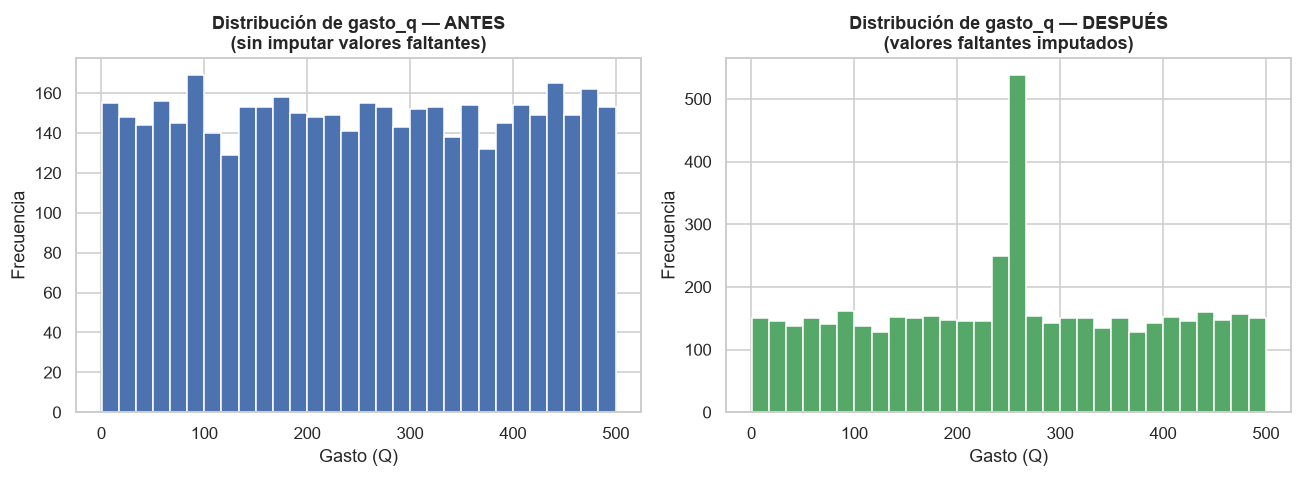

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(df_raw["gasto_q"].apply(parsear_gasto).dropna(), bins=30, color="#4C72B0", edgecolor="white")
axes[0].set_title("Distribución de gasto_q — ANTES\n(sin imputar valores faltantes)")
axes[0].set_xlabel("Gasto (Q)")
axes[0].set_ylabel("Frecuencia")

axes[1].hist(df["gasto_q"], bins=30, color="#55A868", edgecolor="white")
axes[1].set_title("Distribución de gasto_q — DESPUÉS\n(valores faltantes imputados)")
axes[1].set_xlabel("Gasto (Q)")
axes[1].set_ylabel("Frecuencia")

fig.tight_layout()
fig.savefig(os.path.join(IMG_DIR, "08_histograma_gasto_antes_despues.png"), bbox_inches="tight")
plt.show()

**Interpretación:** la forma general de la distribución se conserva, pero se observa un pico adicional
alrededor de Q245–Q270 en el histograma "DESPUÉS". Este pico es un efecto esperado de la estrategia de imputación:
al rellenar el 10.1% de valores faltantes con la mediana de cada categoría, esos ~505 registros se concentran en un
rango estrecho de valores en lugar de dispersarse de forma natural. Es la contrapartida típica de imputar con una
medida de tendencia central: se evita introducir datos inventados o sesgados, a costa de reducir ligeramente la
variabilidad real en esa franja de valores. Se documenta explícitamente para que la limitación quede visible.

C:\Users\pablo\AppData\Local\Temp\ipykernel_8188\4152872314.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="categoria", y="gasto_q", order=orden_categorias,


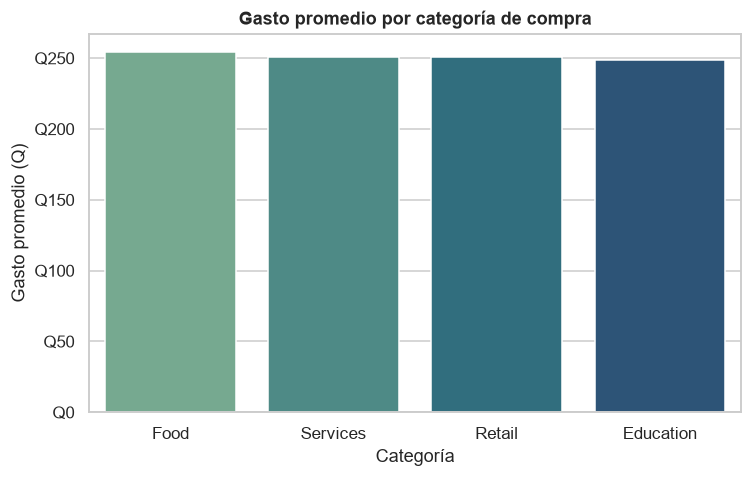

In [20]:
orden_categorias = df.groupby("categoria", observed=True)["gasto_q"].mean().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(data=df, x="categoria", y="gasto_q", order=orden_categorias,
            estimator="mean", errorbar=None, ax=ax, palette="crest")
ax.set_title("Gasto promedio por categoría de compra")
ax.set_xlabel("Categoría")
ax.set_ylabel("Gasto promedio (Q)")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("Q{x:,.0f}"))
fig.tight_layout()
fig.savefig(os.path.join(IMG_DIR, "09_barras_gasto_categoria.png"), bbox_inches="tight")
plt.show()

**Interpretación:** las cuatro categorías (Retail, Services, Education, Food) muestran un gasto promedio muy
similar entre sí (todas en torno a Q248–Q253), lo que sugiere que, en este dataset, el tipo de compra no es un
factor determinante del monto gastado.

C:\Users\pablo\AppData\Local\Temp\ipykernel_8188\1455392414.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="ciudad", y="gasto_q", order=orden_ciudades,


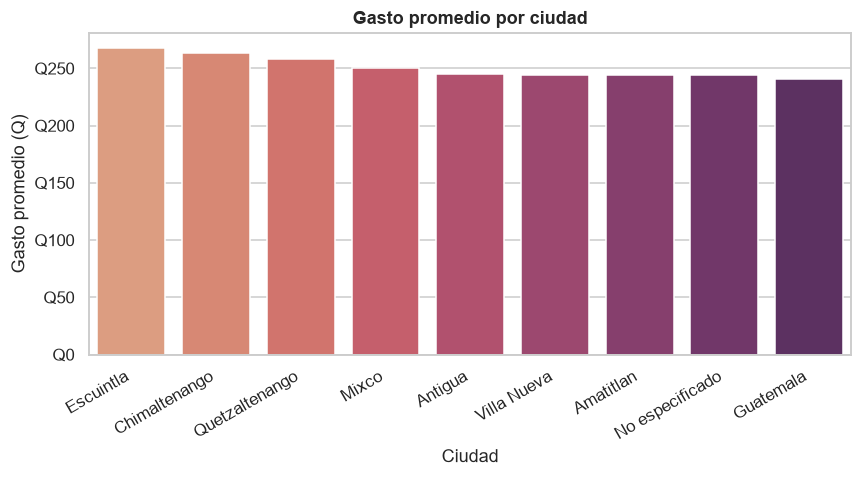

In [21]:
orden_ciudades = df.groupby("ciudad", observed=True)["gasto_q"].mean().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=df, x="ciudad", y="gasto_q", order=orden_ciudades,
            estimator="mean", errorbar=None, ax=ax, palette="flare")
ax.set_title("Gasto promedio por ciudad")
ax.set_xlabel("Ciudad")
ax.set_ylabel("Gasto promedio (Q)")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("Q{x:,.0f}"))
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
fig.tight_layout()
fig.savefig(os.path.join(IMG_DIR, "10_barras_gasto_ciudad.png"), bbox_inches="tight")
plt.show()

**Interpretación:** el gasto promedio por ciudad es homogéneo entre las ocho ciudades registradas, sin
outliers evidentes; la categoría `"No especificado"` (proveniente de los valores faltantes de ciudad) se mantiene en
un rango similar al resto, señal de que la imputación de `gasto_q` no introdujo sesgos por ubicación.

C:\Users\pablo\AppData\Local\Temp\ipykernel_8188\3313739150.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteo_genero.index, y=conteo_genero.values, ax=ax, palette="mako")


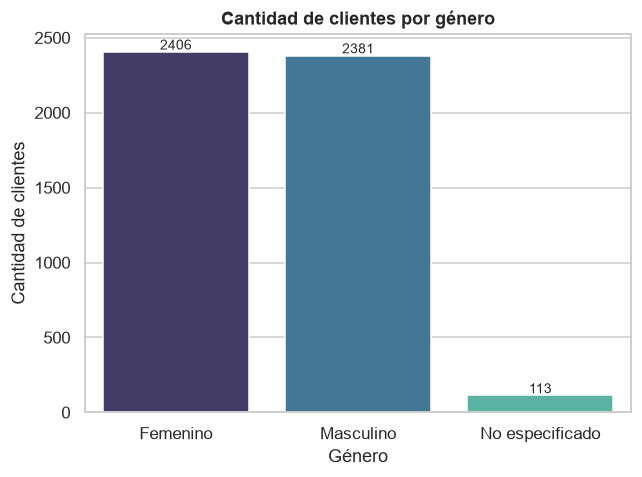

In [22]:
fig, ax = plt.subplots(figsize=(6, 4.5))
conteo_genero = df["genero"].value_counts()
sns.barplot(x=conteo_genero.index, y=conteo_genero.values, ax=ax, palette="mako")
ax.set_title("Cantidad de clientes por género")
ax.set_xlabel("Género")
ax.set_ylabel("Cantidad de clientes")
for i, v in enumerate(conteo_genero.values):
    ax.text(i, v + 15, str(v), ha="center", fontsize=9)
fig.tight_layout()
fig.savefig(os.path.join(IMG_DIR, "11_barras_genero.png"), bbox_inches="tight")
plt.show()

**Interpretación:** la distribución por género está prácticamente balanceada entre "Masculino" y "Femenino"
(ambos por encima de 2,200 clientes), mientras que el grupo `"No especificado"` —resultado de valores originalmente
vacíos— representa una fracción pequeña (~2%) del total, consistente con el porcentaje de nulos detectado en el
diagnóstico inicial.

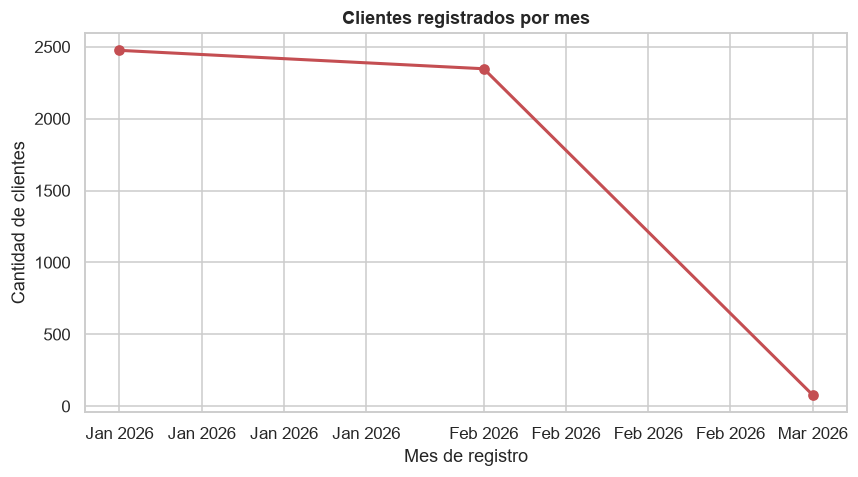

In [23]:
registros_por_mes = (
    df.set_index("fecha_registro")
    .resample("MS")
    .size()
    .rename("clientes_registrados")
)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(registros_por_mes.index, registros_por_mes.values, marker="o", color="#C44E52", linewidth=2)
ax.set_title("Clientes registrados por mes")
ax.set_xlabel("Mes de registro")
ax.set_ylabel("Cantidad de clientes")
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b %Y"))
fig.tight_layout()
fig.savefig(os.path.join(IMG_DIR, "12_serie_registros_mes.png"), bbox_inches="tight")
plt.show()

**Interpretación:** el volumen de registros se mantiene relativamente estable mes a mes dentro del periodo
observado (enero-febrero 2026), sin picos ni caídas abruptas, lo que es consistente con un proceso de registro de
clientes continuo y sin eventos atípicos.

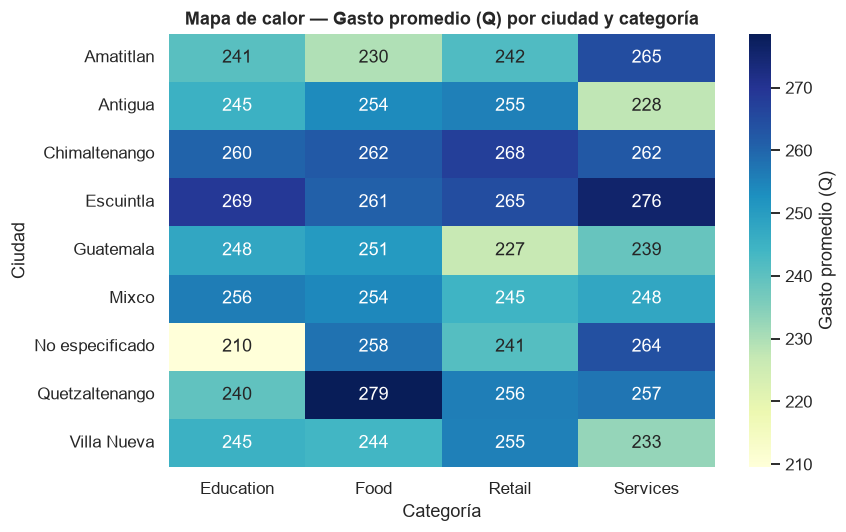

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot_gasto_promedio, annot=True, fmt=".0f", cmap="YlGnBu", cbar_kws={"label": "Gasto promedio (Q)"}, ax=ax)
ax.set_title("Mapa de calor — Gasto promedio (Q) por ciudad y categoría")
ax.set_xlabel("Categoría")
ax.set_ylabel("Ciudad")
fig.tight_layout()
fig.savefig(os.path.join(IMG_DIR, "13_heatmap_ciudad_categoria.png"), bbox_inches="tight")
plt.show()

**Interpretación:** el mapa de calor confirma visualmente lo observado en la tabla pivote: no existen
combinaciones de ciudad-categoría con un gasto promedio marcadamente distinto al resto; los valores se mueven en un
rango moderado (Q210–Q279), reforzando que, en este dataset, el gasto no depende fuertemente de la ubicación ni del
tipo de compra.

## 7. Exportación del dataset limpio

Se exporta el dataset depurado en formato CSV y Parquet, listo para ser reutilizado en análisis posteriores.

In [25]:
df_export = df.copy()
df_export["fecha_registro"] = df_export["fecha_registro"].dt.strftime("%Y-%m-%d")

df_export.to_csv("dataset_limpio.csv", index=False)
df.to_parquet("dataset_limpio.parquet", index=False)

print("Archivos exportados: dataset_limpio.csv, dataset_limpio.parquet")
df_export.head(10)

Archivos exportados: dataset_limpio.csv, dataset_limpio.parquet


,id_cliente,nombre,genero,fecha_registro,gasto_q,ciudad,categoria
0,502609,Paola Morales,Masculino,2026-02-27,250.28,Antigua,Retail
1,500588,Ana Diaz,Femenino,2026-02-24,371.80,Villa Nueva,Services
2,502408,Maria Paz,Masculino,2026-01-15,373.33,Quetzaltenango,Retail
3,501688,Ana Mejia,Femenino,2026-01-18,361.23,Quetzaltenango,Education
4,502916,Carlos Mendez,Femenino,2026-01-29,339.01,Amatitlan,Retail
5,504200,Oscar Rojas,Masculino,2026-01-09,138.22,Antigua,Retail
6,502029,Isabel Ramirez,Masculino,2026-02-05,166.31,Villa Nueva,Services
7,501366,Pedro Herrera,Masculino,2026-02-12,405.62,Amatitlan,Education
8,502614,Patricia Soto,Femenino,2026-01-11,222.88,Guatemala,Retail
9,502794,Pablo Perez,Masculino,2026-02-06,287.37,Escuintla,Retail


## 8. Conclusiones

- El dataset original presentaba **100 filas duplicadas exactas** (2% del total), **dos formatos de fecha**, **dos
  convenciones de separador decimal**, texto sin estandarizar (espacios y mayúsculas inconsistentes) en `nombre`,
  `genero`, `ciudad` y `categoria`, y valores faltantes en `genero` (2.3%), `ciudad` (4.5%) y `gasto_q` (10.1%).
- Tras el proceso de limpieza, el dataset quedó **libre de duplicados y de valores nulos**, con tipos de dato
  consistentes (`datetime64` para fechas, `float` para montos, `category` para variables categóricas).
- La estandarización de texto fue indispensable para poder construir tablas pivote y agregaciones confiables: sin
  ella, una misma ciudad como "Antigua" se fragmentaba en hasta 5 categorías distintas.
- Las visualizaciones muestran un dataset relativamente homogéneo: ni la ciudad ni la categoría de compra parecen
  ser factores determinantes del monto gastado, y la distribución por género está balanceada.
- El dataset limpio (`dataset_limpio.csv` / `.parquet`) queda disponible como insumo confiable para análisis
  posteriores más profundos (por ejemplo, segmentación de clientes o modelos predictivos de gasto).